#### Libary und Settings

#### Funktionen und Daten laden

In [6]:
# ============================================================
# 1) IPCW-Labels + Weights (deine Funktion)
# ============================================================
def create_data_with_ipc_weights(tau: float, data: pd.DataFrame) -> pd.DataFrame:
    data = data.copy()

    kmf = KaplanMeierFitter()
    kmf.fit(
        np.asarray(data["time"], dtype=float),
        event_observed=np.asarray(1 - data["event"].astype(int), dtype=bool),
    )

    conditions = [
        (data["time"] <= tau) & (data["event"] == 1),  # event by tau
        (data["time"] > tau),                          # survived beyond tau (strict!)
        (data["time"] <= tau) & (data["event"] == 0),  # censored by/before tau
    ]
    choices = [0, 1, 999]
    data["survived"] = np.select(conditions, choices, default=999)

    t = np.asarray(data["time"], dtype=float)
    G_t = kmf.survival_function_at_times(t).values.flatten()
    G_tau = float(kmf.survival_function_at_times(tau).values.flatten()[0])

    eps = 1e-12
    G_t = np.clip(G_t, eps, 1.0)
    G_tau = max(G_tau, eps)

    w_event = 1.0 / G_t
    w_tau = 1.0 / G_tau

    data["weights_ipcw"] = np.where(
        data["survived"] == 1,
        w_tau,
        np.where(data["survived"] == 0, w_event, 0.0),
    )

    s = data["weights_ipcw"].sum()
    if s > 0:
        data["weights_ipcw"] /= s

    return data

# ============================================================
# 2) Preprocessor (One-Hot) für GBSG2
# ============================================================
def make_preprocessor(df: pd.DataFrame, feature_cols):
    cat_cols = df[feature_cols].select_dtypes(include=["object", "category"]).columns.tolist()
    num_cols = [c for c in feature_cols if c not in cat_cols]

    try:
        ohe = OneHotEncoder(handle_unknown="ignore", sparse_output=False)
    except TypeError:
        ohe = OneHotEncoder(handle_unknown="ignore", sparse=False)

    return ColumnTransformer(
        transformers=[("cat", ohe, cat_cols), ("num", "passthrough", num_cols)],
        remainder="drop",
    )

def _feature_names(pre, n_features: int):
    if hasattr(pre, "get_feature_names_out"):
        try:
            return list(pre.get_feature_names_out())
        except Exception:
            pass
    return [f"x{i}" for i in range(n_features)]

# ============================================================
# 3) Hyperparameter-Optimierung (K-Fold)
# ============================================================

def weighted_brier(y_true, p, w):
    return float(np.average((y_true - p) ** 2, weights=w))

def tune_params_for_tau_parallel(
    tau,
    param_grid,
    n_splits=3,
    random_state=42,
    n_jobs=-1,
    verbose=10,
    backend="loky",   # "loky" (Prozesse) oder "threading" (Threads)
    data_df=None,
    feature_cols=None,
):
    kf = KFold(n_splits=n_splits, shuffle=True, random_state=random_state)

    def eval_one_param(params):
        fold_scores = []
        for tr_idx, va_idx in kf.split(data_df):
            df_tr = data_df.iloc[tr_idx].copy()
            df_va = data_df.iloc[va_idx].copy()

            # wie bei dir (leichte Näherung, da KM je Fold+Split neu gefittet wird)
            df_tr_tau = create_data_with_ipc_weights(tau, df_tr)
            df_va_tau = create_data_with_ipc_weights(tau, df_va)

            pre = make_preprocessor(df_tr_tau, feature_cols)
            X_tr = pre.fit_transform(df_tr_tau[feature_cols])
            X_va = pre.transform(df_va_tau[feature_cols])

            y_tr = df_tr_tau["survived"].astype(int).to_numpy()
            w_tr = df_tr_tau["weights_ipcw"].to_numpy()

            y_va = df_va_tau["survived"].astype(int).to_numpy()
            w_va = df_va_tau["weights_ipcw"].to_numpy()

            model = DecisionTreeBaggingClassifier(params)
            model.fit(X_tr, y_tr, sample_weights=w_tr)

            _, p_va = model.predict_proba(X_va)

            m = (w_va > 0)  # 999 hat 0 => ignorieren
            fold_scores.append(weighted_brier(y_va[m], p_va[m], w_va[m]))

        return (params, float(np.mean(fold_scores)), float(np.std(fold_scores)))

    results = Parallel(n_jobs=n_jobs, verbose=verbose, backend=backend)(
        delayed(eval_one_param)(params) for params in param_grid
    )

    results.sort(key=lambda x: x[1])  # kleinster Brier ist besser
    best_params, best_mean, best_std = results[0]
    return best_params, results

# ============================================================
# 4) Daten laden
# ============================================================
data = load_gbsg2()
X, y = data

data_df = X.copy()
data_df["time"] = y["time"].astype(float)
data_df["event"] = y["cens"].astype(bool)

feature_cols = list(X.columns)



In [5]:
import os
import pickle
import pandas as pd
from sksurv.datasets import load_gbsg2
import numpy as np
from lifelines import KaplanMeierFitter
from class_DecisionTreeBaggingClassifier import DecisionTreeBaggingClassifier
import matplotlib.pyplot as plt
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.model_selection import KFold
from utils import calculate_ijk_jahn_variance, calculate_ijk_wager_variance, calculate_bootstrap_variance
from utils_AJ import calculate_contributions_variance
from joblib import Parallel, delayed
import matplotlib.pyplot as plt

# -----------------------------
#  Settings
# -----------------------------
taus = [745, 1500, 2135]

B_1 = 200
text_plot = "B1_200"

params_final = {
    "n_estimators": 50000,
    "max_depth": 5,
    "min_samples_split": 5,
    "max_features": "sqrt",
    "random_state": 42,
    "weighted_bootstrapping": True,
}

# -----------------------------
# 1) Patienten (Paper)
# -----------------------------
patients = pd.DataFrame({
    "horTh":   ["no", "no", "no"],
    "age":     [24, 53, 73],
    "menostat":["Pre","Post","Post"],
    
    "tsize":   [25, 25, 25],
    "tgrade":  ["II","II","II"],
    "pnodes":  [3, 3, 3],
    "progrec": [32, 32, 32],
    "estrec":  [36, 36, 36],
})



#### Hyperparameter Optimierung


In [3]:
#param_grid = [
#    {
#        "n_estimators": n_estimators,
#        "max_depth": max_depth,
#        "min_samples_split": min_samples_split,
#        "max_features": max_features,
#        "random_state": 42,
#        "weighted_bootstrapping": True,
#    }
#    for n_estimators in [1000]
#    for max_depth in [3, 4, 5, 6]
#    for min_samples_split in range(2, 11)
#    for max_features in ["sqrt", "log2"]
#]
#
#
#best_params1, results1 = tune_params_for_tau_parallel(
#    tau=taus[0],
#    param_grid=param_grid,
#    n_splits=10,
#    n_jobs=-1,
#    backend="loky", 
#    verbose=10,
#    data_df=data_df,
#    feature_cols=feature_cols,
#)
#
#best_params2, results2 = tune_params_for_tau_parallel(
#    tau=taus[1],
#    param_grid=param_grid,
#    n_splits=10,
#    n_jobs=-1,
#    backend="loky", 
#    verbose=10,
#    data_df=data_df,
#    feature_cols=feature_cols,
#)
#
#best_params3, results3 = tune_params_for_tau_parallel(
#    tau=taus[2],
#    param_grid=param_grid,
#    n_splits=10,
#    n_jobs=-1,
#    backend="loky", 
#    verbose=10,
#    data_df=data_df,
#    feature_cols=feature_cols
#)


#### Fit auf ganzem Datensatz + Predictions für mehrere τ

In [7]:
# ============================================================
# 6) Fit pro tau + Predict + Speichern (inkl. df_tau & feature_names)
# ============================================================
os.makedirs("./real_data_B50000", exist_ok=True)
fit_cache_path = f"./real_data_B50000/fit_cache_{text_plot}.pkl"

if os.path.exists(fit_cache_path):
    with open(fit_cache_path, "rb") as f:
        cache_obj = pickle.load(f)
    all_outputs = cache_obj["all_outputs"]
    pred_summary = cache_obj["pred_summary"]
    print(f"Loaded cached fits from {fit_cache_path}")
else:
    all_outputs = {}
    summary_rows = []

    for tau in taus:
        df_tau = create_data_with_ipc_weights(tau=tau, data=data_df)

        # Safety check
        w = df_tau["weights_ipcw"].to_numpy()
        s = df_tau["survived"].to_numpy()
        assert np.isclose(w.sum(), 1.0), "weights_ipcw must sum to 1"
        assert np.all(w[s == 999] == 0), "999 rows must have exactly zero weight"
        assert set(np.unique(s[w > 0])) <= {0, 1}, "nonzero-weight labels must be only {0,1}"

        pre = make_preprocessor(df_tau, feature_cols)
        X_fit = pre.fit_transform(df_tau[feature_cols])

        y_fit = df_tau["survived"].astype(int).to_numpy()
        w_fit = df_tau["weights_ipcw"].to_numpy()

        model = DecisionTreeBaggingClassifier(params_final)
        model.fit(X_fit, y_fit, sample_weights=w_fit)

        X_pat = pre.transform(patients[feature_cols])
        preds_trees, p_pat = model.predict_proba(X_pat)

        feat_names = _feature_names(pre, X_fit.shape[1])

        all_outputs[tau] = {
            "model": model,
            "preprocessor": pre,
            "preds_trees": preds_trees,  # (B, 3)
            "p_mean": p_pat,             # (3,)
            "df_tau": df_tau,            # wichtig für weights_ipcw
            "feature_names": feat_names,
        }

        summary_rows.append({
            "tau": tau,
            "patient_1": float(p_pat[0]),
            "patient_2": float(p_pat[1]),
            "patient_3": float(p_pat[2]),
        })

        with open(f"./real_data_B50000/_{tau}.txt", "w") as f:
            f.write(str(np.round(df_tau["survived"].value_counts(dropna=False, normalize=True), 2)))

    pred_summary = pd.DataFrame(summary_rows).set_index("tau")

    with open(fit_cache_path, "wb") as f:
        pickle.dump({"all_outputs": all_outputs, "pred_summary": pred_summary}, f)
    print(f"Saved cached fits to {fit_cache_path}")

print("Predictions (mean over trees):")
display(pred_summary)


Saved cached fits to ./real_data_B50000/fit_cache_B1_200.pkl
Predictions (mean over trees):


,patient_1,patient_2,patient_3
tau,,,
745,0.413786,0.814322,0.811603
1500,0.300672,0.637161,0.646923
2135,0.211030,0.490884,0.481652


#### Varianzschätzer auf die Predictions

Patient: 1 , Zeitpunkte tau: 745
Anzahl an Boostrap-Wiederholungen


50000

Größe der Trainingsstichprobe


686

Anzahl an Beobachtungen mit positivem Gewicht


...

0.014313857428026365

Bias-Korrekturterm Jahn


0.0006576713093412236

Bias-korrigierter Varianzterm von Jahn


0.0067666901094022075

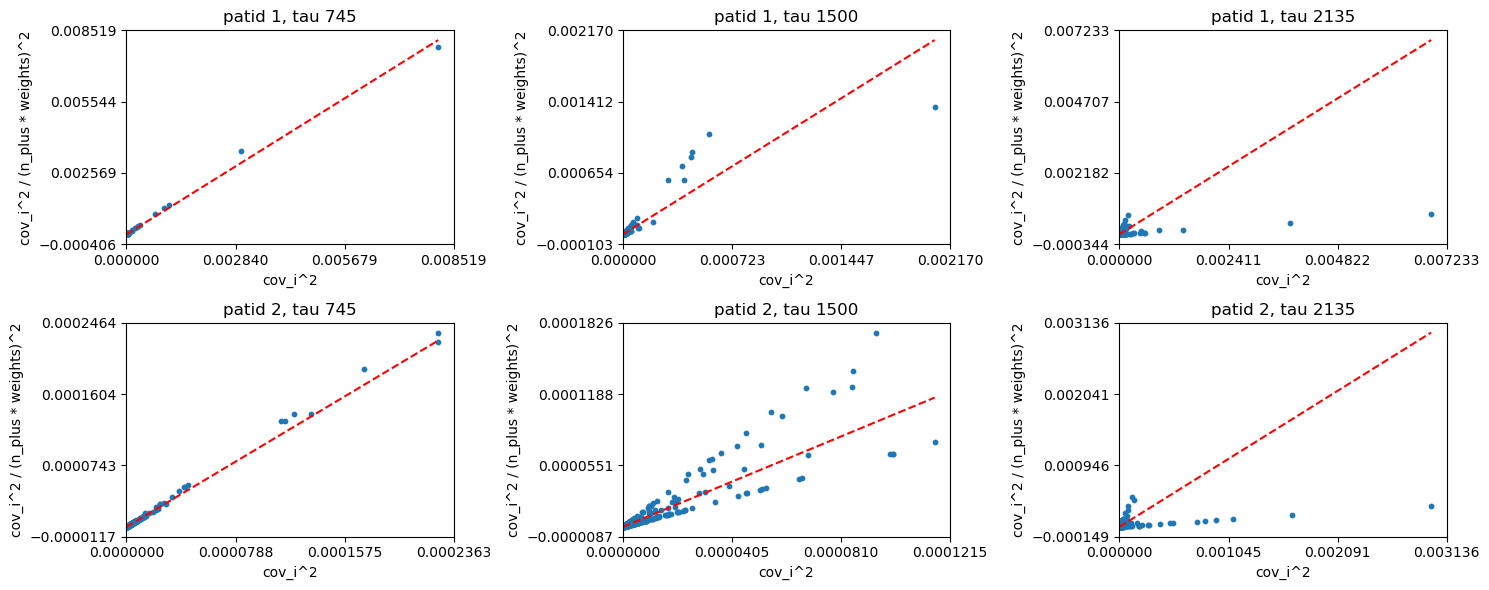

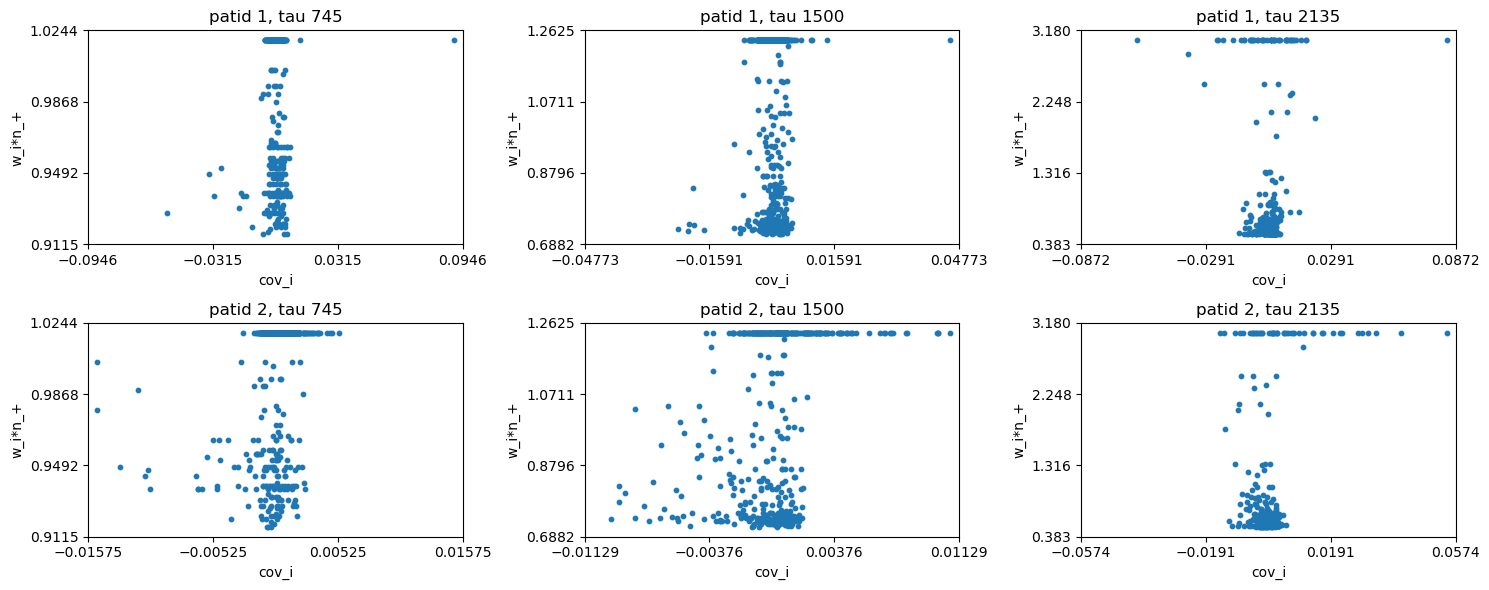

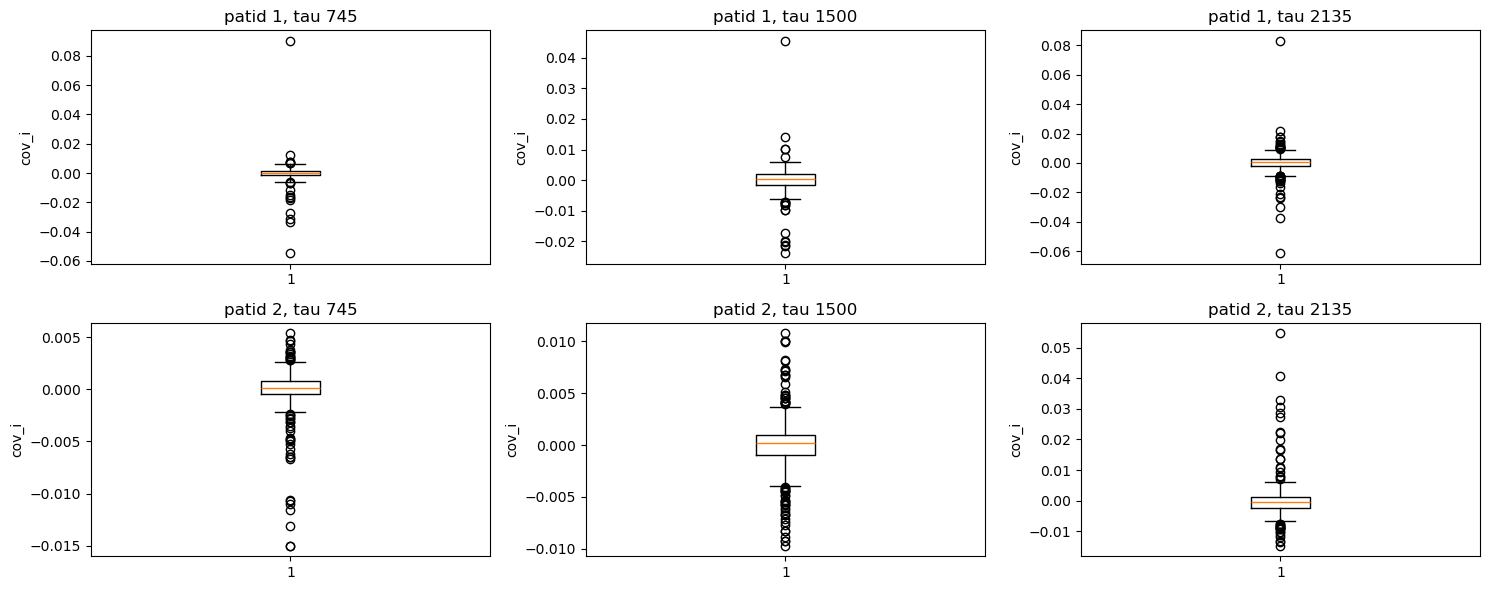

In [8]:
import matplotlib.ticker as mticker

fig1, axes1 = plt.subplots(2, len(taus), figsize=(15, 6))
fig2, axes2 = plt.subplots(2, len(taus), figsize=(15, 6))
fig3, axes3 = plt.subplots(2, len(taus), figsize=(15, 6))

for i, patid in enumerate([1, 2]):
    for j, tau in enumerate(taus):

        model = all_outputs[tau]["model"]
        pre = all_outputs[tau]["preprocessor"]
        df_tau = all_outputs[tau]["df_tau"]
        feat_names = all_outputs[tau]["feature_names"]

        X_pat = pre.transform(patients[feature_cols])
        X_point_df = pd.DataFrame(X_pat[(patid-1):(patid)], columns=feat_names)

        B, n, n_plus, Tnb, Nbi, weights, cov_i, cov_i_wager, array, hatV, sumw, df_train = \
            calculate_contributions_variance(model, X_point_df, df_tau)

        w = np.asarray(weights).reshape(-1)
        c = np.asarray(cov_i).reshape(-1)
        x = c ** 2
        y = 1 / ( (n_plus * w) ** 2) * c ** 2  
        ax = axes1[i, j]
        ax.scatter(x, y, s=10)        
        m = max(np.max(x), np.max(y))
        ax.plot([0, m], [0, m], 'r--')
        ax.set_title(f"patid {patid}, tau {tau}")
        ax.set_aspect('auto')
        ax.set_xlabel("cov_i^2")
        ax.set_ylabel("cov_i^2 / (n_plus * weights)^2")
        #ax.ticklabel_format(style='sci', axis='both', scilimits=(0, 0))
        ax.xaxis.set_major_locator(mticker.LinearLocator(4))
        ax.yaxis.set_major_locator(mticker.LinearLocator(4))
        ax.set_xlim(left=0)
        ax.xaxis.set_major_locator(mticker.LinearLocator(4))

          
        w = np.asarray(weights).reshape(-1)[np.asarray(weights).ravel() != 0]
        c = np.asarray(cov_i).reshape(-1)[np.asarray(weights).ravel() != 0]
        x = c 
        y = w*n_plus 
        ax = axes2[i, j]
        ax.scatter(x, y, s=10)        
        m = np.max(np.abs(x)) * 1.05
        ax.set_xlim(-m, m)        
        ax.set_title(f"patid {patid}, tau {tau}")
        ax.set_aspect('auto')
        ax.set_xlabel("cov_i")
        ax.set_ylabel("w_i*n_+")
        #ax.ticklabel_format(style='sci', axis='both', scilimits=(0, 0))
        ax.xaxis.set_major_locator(mticker.LinearLocator(4))
        ax.yaxis.set_major_locator(mticker.LinearLocator(4))
       

        ax = axes3[i, j]
        ax.boxplot(cov_i[weights != 0])
        ax.set_title(f"patid {patid}, tau {tau}")
        ax.set_ylabel("cov_i")
        
        print("Patient:", patid, ", Zeitpunkte tau:",tau)

        print("Anzahl an Boostrap-Wiederholungen")
        display(B)

        print("Größe der Trainingsstichprobe")
        display(n)

        print("Anzahl an Beobachtungen mit positivem Gewicht")
        display(int(n_plus))

        print("base learner variability (V(T(x,N*))")
        display(hatV.item())

        print("unkorrigierter Varianzterm von Wager: Summe der cov_i^2")
        display(float(np.sum(cov_i**2)))

        print("unkorrigierter Varianzterm von Jahn: Summe der gewichteten cov_i^2")
        display(float(1/n_plus ** 2 * np.sum(np.asarray(cov_i).reshape(-1)[weights != 0]**2 / np.asarray(weights).reshape(-1)[weights != 0]**2)))

        print("Bias-Korrekturterm Wager: n/B * V(T(x,N*)")
        display((n/B*hatV).item())

        print("Bias-korrigierter Varianzterm von Wager")
        display(float(np.sum((cov_i**2)))-(n/B*hatV).item())
        #display(float(np.sum((cov_i**2)[cov_i**2 < 0.0125]))-(n/B*hatV).item())

        print("Bias-Korrekturterm Jahn")
        display(float(1/(n_plus**2)*(n/B*hatV).item()*sumw))
        
        print("Bias-korrigierter Varianzterm von Jahn")
        display(float(1/n_plus ** 2 * np.sum((np.asarray(cov_i).reshape(-1))[(weights != 0)]**2 / np.asarray(weights).reshape(-1)[weights != 0]**2)-1/(n_plus**2)*(n/B*hatV).item()*sumw))

fig1.tight_layout()
fig2.tight_layout()
fig3.tight_layout()

fig1.savefig("plot_cov_ratio.png", dpi=300, bbox_inches="tight")
fig2.savefig("plot_cov_weights.png", dpi=300, bbox_inches="tight")
fig3.savefig("plot_boxplots.png", dpi=300, bbox_inches="tight")        



In [11]:
def plot_dodged_intervals_short(df_res, patients_to_plot=(1, 2), z=1.96, text_plot=""):
    # df_res: tau, patient, pred, std_wager, std_jahn, std_boot
    from pathlib import Path
    import numpy as np
    import matplotlib.pyplot as plt

    out_dir = Path("./real_data_B50000")
    out_dir.mkdir(parents=True, exist_ok=True)
    df = df_res[df_res["patient"].isin(patients_to_plot)].copy()

    long = df.melt(
        id_vars=["tau", "patient", "pred"],
        value_vars=["std_wager", "std_jahn"],
        var_name="estimator",
        value_name="std",
    )
    long["estimator"] = long["estimator"].str.replace("std_", "", regex=False)
    long["low"] = np.clip(long["pred"] - z * long["std"], 0, 1)
    long["high"] = np.clip(long["pred"] + z * long["std"], 0, 1)

    # --- Labels (Legend) ---
    jahn_ = r"$\hat{V}_{IJ-U}^{wB}$"
    wager_ = r"$\hat{V}_{IJ-U}^{B}$"
    legend_label = {"jahn": jahn_, "wager": wager_}

    # --- Reihenfolge links->rechts: jahn, wager, boot ---
    # (Offsets steuern die Position; draw_order steuert zusätzlich die Zeichenreihenfolge bei Overlap)
    offsets = {"jahn": -35, "wager": 0}
    draw_order = ["jahn", "wager"]
    zmap = {"jahn": 2, "wager": 3}

    color_map = {
        "pred": "black",
        "wager": "#ff7f0e",
        "jahn": "#1f77b4",
    }

    for p in sorted(long["patient"].unique()):
        plt.figure(figsize=(8, 5))
        sub = long[long["patient"] == p].sort_values(["tau", "estimator"])
        base = df[df["patient"] == p].sort_values("tau")

        # --- pred als horizontale kurze Linie pro tau ---
        pad = 20
        taus = base["tau"].astype(float).to_numpy()
        preds = base["pred"].astype(float).to_numpy()

        left = taus + min(offsets.values()) - pad
        right = taus + max(offsets.values()) + pad

        plt.hlines(
            y=preds,
            xmin=left,
            xmax=right,
            colors=color_map["pred"],
            linewidth=2.0,
            label="pred (common)",
            zorder=1,
        )

        # --- Errorbars in gewünschter Reihenfolge ---
        for est in draw_order:
            e = sub[sub["estimator"] == est].sort_values("tau")
            x = e["tau"].astype(float).to_numpy() + offsets[est]
            y = e["pred"].astype(float).to_numpy()
            lo = e["low"].astype(float).to_numpy()
            hi = e["high"].astype(float).to_numpy()
            yerr = np.vstack([y - lo, hi - y])

            eb = plt.errorbar(
                x, y, yerr=yerr,
                fmt="o", capsize=4,
                color=color_map[est],
                label=rf"95% CI ({legend_label[est]})",
                zorder=zmap[est],
            )

            # stellt sicher, dass auch caps + balken die gleiche Reihenfolge haben
            line, caplines, barlinecols = eb
            line.set_zorder(zmap[est])
            for c in caplines:
                c.set_zorder(zmap[est])
            for b in barlinecols:
                b.set_zorder(zmap[est])

        plt.ylim(0, 1)
        plt.xlabel(r"$\tau$ (days)")
        plt.xticks([745, 1500, 2135])
        plt.ylabel(r"$\hat{\theta}_{\tau}(x_{})=\hat{P}\left(T^*>\tau \mid X=x_{}\right)$")
        plt.grid(alpha=0.2)

        # --- Legend in fester Reihenfolge ---
        ax = plt.gca()
        handles, labels = ax.get_legend_handles_labels()

        desired = [
            "pred (common)",
            rf"95% CI ({jahn_})",
            rf"95% CI ({wager_})",
        ]
        label_to_handle = {lab: h for h, lab in zip(handles, labels)}
        ordered_handles = [label_to_handle[lab] for lab in desired if lab in label_to_handle]
        ordered_labels = [lab for lab in desired if lab in label_to_handle]
        plt.legend(ordered_handles, ordered_labels)

        plt.tight_layout()
        plt.savefig(out_dir / f"patient_{p}_{text_plot}.png", dpi=300, bbox_inches="tight")
        plt.show()

def safe_sqrt(v):
    return float(np.sqrt(max(float(v), 0.0)))


Saved variance results to ./real_data_B50000/var_results_B1_200.csv


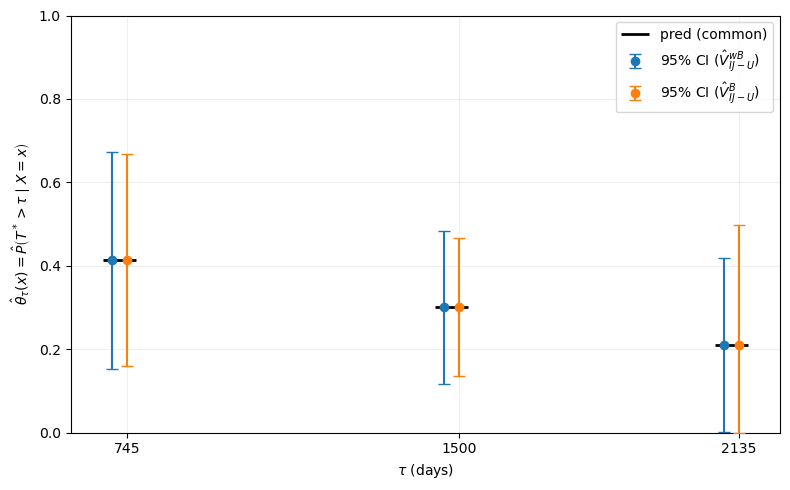

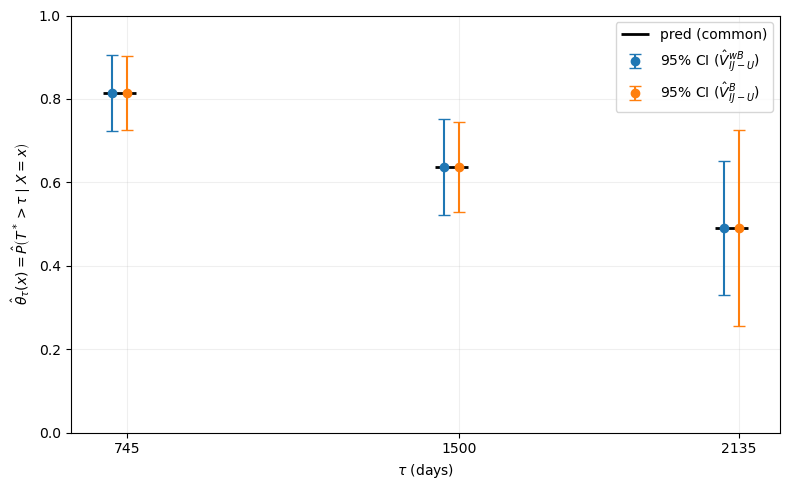

In [12]:
# ============================================================
# 7) Varianzschätzer für jedes tau & jeden Patienten berechnen
# ============================================================
var_cache_path = f"./real_data_B50000/var_results_{text_plot}.csv"

if os.path.exists(var_cache_path):
    var_results = pd.read_csv(var_cache_path)
    print(f"Loaded cached variance results from {var_cache_path}")
else:
    var_rows = []
    for tau in taus:
        model = all_outputs[tau]["model"]
        pre = all_outputs[tau]["preprocessor"]
        df_tau = all_outputs[tau]["df_tau"]
        feat_names = all_outputs[tau]["feature_names"]

        X_pat = pre.transform(patients[feature_cols])  # (3, p)

        for j in [0, 1]:
            X_point_df = pd.DataFrame(X_pat[j:j+1], columns=feat_names)

            # Prediction
            _, pred = model.predict_proba(X_point_df.values)
            pred = float(np.ravel(pred)[0])

            # IJ-Kahn
            v_jahn_biased, bc1, bc2 = calculate_ijk_jahn_variance(model, X_point_df, df_tau)
            v_jahn_biased = float(np.ravel(v_jahn_biased)[0])
            bc1 = float(np.ravel(bc1)[0])
            std_jahn_corr = safe_sqrt(v_jahn_biased - bc1)

            # IJ-Wager
            v_wager_biased, bcw = calculate_ijk_wager_variance(model, X_point_df, df_tau)
            v_wager_biased = float(np.ravel(v_wager_biased)[0])
            bcw = float(np.ravel(bcw)[0])
            std_wager_corr = safe_sqrt(v_wager_biased - bcw)

            # bootstrap
            X_point_raw = patients.iloc[[j]].copy()
            #var_boot = calculate_bootstrap_variance_parallel(
            #    params_rf=params_final,
            #    df_raw=data_df,
            #    tau=tau,
            #    X_pred_point_raw=X_point_raw,
            #    feature_cols=feature_cols,
            #    seed=42,
            #    B_1=B_1,
            #    n_jobs=-1,
            #    backend="loky",
            #    verbose=5,
            #)
            var_rows.append({
                "tau": tau,
                "patient": j + 1,
                "pred": pred,
                "std_wager": std_wager_corr,
                "std_jahn": std_jahn_corr,
            #    "std_boot": safe_sqrt(var_boot),
            })

    var_results = pd.DataFrame(var_rows).sort_values(["tau", "patient"]).reset_index(drop=True)
    var_results.to_csv(var_cache_path, index=False)
    print(f"Saved variance results to {var_cache_path}")

#display(var_results)
plot_dodged_intervals_short(var_results, patients_to_plot=(1, 2), text_plot=text_plot)
